In [1]:
# -*- coding: utf-8 -*-
# Preprocessing for waist-mounted ActiGraph-style raw accelerometry (X,Y,Z in g)
# Assumptions confirmed:
#   • ~30 Hz, 6-minute bouts, no timestamps, units in g
#   • Device frame varies; align to anatomical AP, ML, VT
#   • Trim fixed seconds at start/end
#   • Save each subject’s preprocessed CSV to csv_preprocessed/

from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt  # SciPy official API
from scipy.stats import spearmanr  # official: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html
# pandas.read_csv, DataFrame.to_csv — official docs: https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
# scipy.signal.butter, scipy.signal.filtfilt — official docs: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.filtfilt.html
# numpy.interp, linalg.norm, cross — official docs: https://numpy.org/doc/2.2/reference/generated/numpy.interp.html
# https://numpy.org/doc/2.1/reference/generated/numpy.linalg.norm.html
# https://numpy.org/doc/1.25/reference/generated/numpy.cross.html

In [2]:
import numpy as np
import pandas as pd
from scipy import stats

# --- effect sizes ---

def hedges_g(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan
    mx, my = np.mean(x), np.mean(y)
    vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
    sp2 = ((nx-1)*vx + (ny-1)*vy) / (nx+ny-2) if (nx+ny-2) > 0 else np.nan
    if not np.isfinite(sp2) or sp2 <= 0:
        return np.nan
    d = (mx - my) / np.sqrt(sp2)
    # small-sample bias correction
    J = 1 - (3 / (4*(nx+ny) - 9)) if (nx+ny) > 2 else 1.0
    return J * d

def cliffs_delta(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    nx, ny = len(x), len(y)
    if nx == 0 or ny == 0:
        return np.nan
    # Efficient computation using broadcasting with memory guard
    # Fall back to rank-based method for large arrays
    if nx*ny <= 2_000_000:
        comp = np.subtract.outer(x, y)
        delta = (np.sum(comp > 0) - np.sum(comp < 0)) / (nx*ny)
        return float(delta)
    # Rank-based approximation (equivalent)
    ranks = stats.rankdata(np.concatenate([x, y]))
    rx = ranks[:nx].sum()
    U = rx - nx*(nx+1)/2
    delta = (2*U)/(nx*ny) - 1
    return float(delta)

# --- multiple testing (Benjamini–Hochberg FDR) ---

def fdr_bh(pvals):
    p = np.asarray(pvals, float)
    n = p.size
    order = np.argsort(p)
    ranks = np.arange(1, n+1)
    adj = np.empty(n, float)
    adj[order] = np.minimum.accumulate((p[order][::-1] * n / ranks[::-1]))[::-1]
    adj = np.clip(adj, 0, 1)
    return adj

# --- main analysis ---

def analyze_group_differences(df, group_col="group", groups=("Control", "MS"), features=None, alpha=0.05):
    if features is None:
        # all numeric columns except the group column
        features = [c for c in df.columns if c != group_col and pd.api.types.is_numeric_dtype(df[c])]

    g1, g2 = groups
    rows = []
    for feat in features:
        s1 = df.loc[df[group_col] == g1, feat].dropna().astype(float)
        s2 = df.loc[df[group_col] == g2, feat].dropna().astype(float)

        n1, n2 = len(s1), len(s2)
        if n1 < 2 or n2 < 2:
            rows.append({
                "feature": feat, "n_Control": n1, "n_MS": n2,
                "normality_p_Control": np.nan, "normality_p_MS": np.nan,
                "levene_p": np.nan, "test": "insufficient data",
                "statistic": np.nan, "p_value": np.nan,
                "effect_size": np.nan, "effect_name": np.nan,
                "mean_Control": s1.mean() if n1 else np.nan,
                "mean_MS": s2.mean() if n2 else np.nan,
                "std_Control": s1.std(ddof=1) if n1 > 1 else np.nan,
                "std_MS": s2.std(ddof=1) if n2 > 1 else np.nan
            })
            continue

        # normality (Shapiro–Wilk; robust for n up to 5k+)
        try:
            sw1 = stats.shapiro(s1).pvalue if n1 <= 5000 else stats.normaltest(s1).pvalue
            sw2 = stats.shapiro(s2).pvalue if n2 <= 5000 else stats.normaltest(s2).pvalue
        except Exception:
            # fallback: D'Agostino for safety
            sw1 = stats.normaltest(s1).pvalue
            sw2 = stats.normaltest(s2).pvalue

        # variance equality (Levene, center=median helps with mild non-normality)
        lev_p = stats.levene(s1, s2, center='median').pvalue

        approx_normal = (sw1 > alpha) and (sw2 > alpha)

        if approx_normal:
            # Welch’s t-test by default (safer when variances differ)
            t = stats.ttest_ind(s1, s2, equal_var=False)
            stat, p = t.statistic, t.pvalue
            es = hedges_g(s1, s2)
            test_name = "Welch t"
            es_name = "Hedges g"
        else:
            # Nonparametric
            u = stats.mannwhitneyu(s1, s2, alternative='two-sided', method='asymptotic')
            stat, p = u.statistic, u.pvalue
            es = cliffs_delta(s1, s2)
            test_name = "Mann–Whitney U"
            es_name = "Cliff's delta"

        rows.append({
            "feature": feat,
            "n_Control": n1, "n_MS": n2,
            "normality_p_Control": sw1, "normality_p_MS": sw2,
            "levene_p": lev_p,
            "test": test_name,
            "statistic": stat, "p_value": p,
            "effect_size": es, "effect_name": es_name,
            "mean_Control": s1.mean(), "mean_MS": s2.mean(),
            "std_Control": s1.std(ddof=1), "std_MS": s2.std(ddof=1),
            "median_Control": np.median(s1), "median_MS": np.median(s2)
        })

    res = pd.DataFrame(rows)
    res["p_fdr"] = fdr_bh(res["p_value"].fillna(1.0).values)
    res = res.sort_values("p_fdr", ascending=True).reset_index(drop=True)
    return res

In [3]:
# -------------------------
# Configuration
# -------------------------

@dataclass(frozen=True)
class PreprocConfig:
    target_fs: float = 30.0                 # Hz (final, uniform)
    trim_seconds: float = 10.0              # seconds to drop at start and end
    gravity_lp_hz: float = 0.25             # Hz (LP to estimate gravity)
    step_band_hz: tuple[float, float] = (0.25, 2.5)  # Hz band-pass for step dynamics
    filter_order: int = 4                   # Butterworth order
    out_dir: Path = Path("csv_preprocessed2")

In [4]:
# -------------------------
# Filename parsing
# -------------------------

_filename_re = re.compile(
    r"^(?P<cohort>[CM])(?P<id>\d+)_?(?P<year>\d{4})?_(?P<sixmwd>\d+)\.csv$", re.IGNORECASE
)

def parse_filename(p: Path) -> dict:
    """
    Parse filenames like `M60_2024_1458.csv` or `C01_2016_2147.csv`.
    Returns dict with: cohort ('M'|'C'), subj_id (int), year (int|None), sixmwd (int).
    """
    m = _filename_re.match(p.name)
    if not m:
        raise ValueError(f"Unexpected filename format: {p.name}")
    cohort = m.group("cohort").upper()
    subj_id = int(m.group("id"))
    year = int(m.group("year")) if m.group("year") else None
    sixmwd = int(m.group("sixmwd"))
    return {"cohort": cohort, "subj_id": subj_id, "year": year, "sixmwd": sixmwd}


# -------------------------
# I/O
# -------------------------

def load_xyz_csv(p: Path) -> pd.DataFrame:
    """
    Read CSV with columns exactly X,Y,Z (units in g).
    Enforces float dtype and column order.
    """
    df = pd.read_csv(p, usecols=["X", "Y", "Z"])
    df = df.astype({"X": "float64", "Y": "float64", "Z": "float64"})
    return df


def save_preprocessed(df: pd.DataFrame, src_path: Path, cfg: PreprocConfig) -> Path:
    cfg.out_dir.mkdir(parents=True, exist_ok=True)
    out_path = cfg.out_dir / src_path.name  # keep original basename
    df.to_csv(out_path, index=False)
    return out_path

In [5]:
# -------------------------
# Sampling / trimming / resampling
# -------------------------

def infer_fs_from_length(n_samples: int, bout_seconds: float = 360.0) -> float:
    """
    With no timestamps, infer fs = N / T.
    """
    return float(n_samples) / float(bout_seconds)

def trim_edges(arr: np.ndarray, fs: float, trim_seconds: float) -> np.ndarray:
    """
    Drop fixed seconds at start and end.
    """
    n_trim = int(round(trim_seconds * fs))
    if 2 * n_trim >= len(arr):
        raise ValueError("Trim length too large for signal length.")
    return arr[n_trim: len(arr) - n_trim, :]

def resample_uniform(arr: np.ndarray, src_fs: float, dst_fs: float) -> np.ndarray:
    """
    1-D per-axis linear interpolation to a uniform target length.
    Uses numpy.interp on each column independently.
    """
    if src_fs <= 0 or dst_fs <= 0:
        raise ValueError("Sampling rates must be positive.")
    n_src, d = arr.shape
    dur = (n_src - 1) / src_fs
    n_dst = int(round(dur * dst_fs)) + 1
    oldt = np.linspace(0.0, dur, num=n_src, endpoint=True)
    newt = np.linspace(0.0, dur, num=n_dst, endpoint=True)
    out = np.empty((n_dst, d), dtype=np.float64)
    for j in range(d):
        out[:, j] = np.interp(newt, oldt, arr[:, j])
    return out

In [6]:
# -------------------------
# Filtering and gravity removal
# -------------------------

def butter_lowpass(cut_hz: float, fs: float, order: int = 4):
    if not (0 < cut_hz < fs / 2):
        raise ValueError(f"LP cutoff must be in (0, fs/2). Got {cut_hz} vs fs={fs}.")
    b, a = butter(N=order, Wn=cut_hz, btype="lowpass", fs=fs)
    return b, a

def butter_bandpass(lo_hz: float, hi_hz: float, fs: float, order: int = 4):
    if not (0 < lo_hz < hi_hz < fs / 2):
        raise ValueError("Band edges must satisfy 0 < lo < hi < fs/2.")
    b, a = butter(N=order, Wn=[lo_hz, hi_hz], btype="bandpass", fs=fs)
    return b, a

def zero_phase_filter(x: np.ndarray, b: np.ndarray, a: np.ndarray) -> np.ndarray:
    """
    Apply filtfilt along the first axis (time) for each column.
    """
    y = np.empty_like(x)
    for j in range(x.shape[1]):
        y[:, j] = filtfilt(b, a, x[:, j], axis=0)
    return y

def estimate_gravity_lp(arr: np.ndarray, fs: float, cut_hz: float, order: int) -> np.ndarray:
    """
    Low-pass each axis to estimate the gravity component (in g).
    """
    b, a = butter_lowpass(cut_hz, fs, order=order)
    return zero_phase_filter(arr, b, a)

def remove_gravity(arr: np.ndarray, g_est: np.ndarray) -> np.ndarray:
    """
    Dynamic acceleration = raw - gravity_estimate (elementwise).
    """
    return arr - g_est

In [7]:
# -------------------------
# Orientation alignment to anatomical axes
# -------------------------

def _rodrigues(axis: np.ndarray, theta: float) -> np.ndarray:
    """
    Rodrigues' rotation formula for a unit axis and angle theta (radians).
    Returns a 3x3 rotation matrix.
    """
    ax = axis / (np.linalg.norm(axis) + 1e-12)
    K = np.array([[0, -ax[2], ax[1]],
                  [ax[2], 0, -ax[0]],
                  [-ax[1], ax[0], 0]], dtype=np.float64)
    I = np.eye(3, dtype=np.float64)
    R = I + math.sin(theta) * K + (1 - math.cos(theta)) * (K @ K)
    return R

def rotate_to_vertical(arr_dyn: np.ndarray, g_mean: np.ndarray) -> np.ndarray:
    """
    Rotate dynamic acceleration so that mean gravity points to +Z (VT).
    """
    zhat = np.array([0.0, 0.0, 1.0], dtype=np.float64)
    gvec = g_mean / (np.linalg.norm(g_mean) + 1e-12)
    # If already close to vertical, skip
    dot = np.clip(float(zhat @ gvec), -1.0, 1.0)
    angle = math.acos(dot)
    if angle < 1e-4:
        return arr_dyn.copy()
    axis = np.cross(gvec, zhat)
    if np.linalg.norm(axis) < 1e-8:
        # Opposite direction; rotate around X (any axis orthogonal to z)
        axis = np.array([1.0, 0.0, 0.0], dtype=np.float64)
    R = _rodrigues(axis, angle)
    return arr_dyn @ R.T

def yaw_align_apml(arr_dyn_v: np.ndarray) -> np.ndarray:
    """
    After vertical alignment, find dominant horizontal direction (AP) via PCA
    on [X,Y]; rotate about Z so that AP aligns with +X and ML with +Y.
    """
    # Use covariance of horizontal components
    XY = arr_dyn_v[:, :2]
    # 2x2 covariance
    C = np.cov(XY, rowvar=False)
    # Eigen decomposition (symmetric)
    vals, vecs = np.linalg.eigh(C)
    ap_dir = vecs[:, np.argmax(vals)]  # 2-vector in the XY-plane
    # Angle from +X to ap_dir
    theta = math.atan2(float(ap_dir[1]), float(ap_dir[0]))
    # Rotate by -theta about Z
    c, s = math.cos(-theta), math.sin(-theta)
    Rz = np.array([[c, -s, 0.0],
                   [s,  c, 0.0],
                   [0.0, 0.0, 1.0]], dtype=np.float64)
    return arr_dyn_v @ Rz.T

def align_to_ap_ml_vt(arr_raw_g: np.ndarray, fs: float, cfg: PreprocConfig) -> tuple[np.ndarray, np.ndarray]:
    """
    Estimate gravity (LP), subtract, vertical-align, and yaw-align to get AP, ML, VT.
    Returns:
        apmlvt_dyn : (N,3) dynamic acceleration in anatomical axes
        g_est      : (N,3) gravity estimate used (LP)
    """
    g_est = estimate_gravity_lp(arr_raw_g, fs, cfg.gravity_lp_hz, cfg.filter_order)
    arr_dyn = remove_gravity(arr_raw_g, g_est)
    g_mean = g_est.mean(axis=0)
    arr_v = rotate_to_vertical(arr_dyn, g_mean)
    apmlvt = yaw_align_apml(arr_v)
    return apmlvt, g_est

In [8]:
# -------------------------
# Optional step-band signals and magnitudes
# -------------------------

def bandpass_steps(apmlvt_dyn: np.ndarray, fs: float, cfg: PreprocConfig) -> np.ndarray:
    """
    Zero-phase bandpass in the step frequency band (per axis).
    """
    lo, hi = cfg.step_band_hz
    b, a = butter_bandpass(lo, hi, fs, order=cfg.filter_order)
    return zero_phase_filter(apmlvt_dyn, b, a)

def compute_vm_enmo(raw_g: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    VM (dynamic magnitude after gravity removal isn't ENMO).
    ENMO is defined on raw vector magnitude in g: max(||raw|| - 1, 0).
    Returns:
        vm_raw  : ||raw_g|| (g)
        enmo    : max(vm_raw - 1, 0) (g)
    """
    vm_raw = np.linalg.norm(raw_g, axis=1)
    enmo = np.maximum(vm_raw - 1.0, 0.0)
    return vm_raw, enmo

In [9]:
# -------------------------
# End-to-end per-file preprocessing
# -------------------------

def preprocess_file(path: Path, cfg: PreprocConfig) -> Path:
    """
    Pipeline:
      1) Load X,Y,Z in g.
      2) Infer fs from length and 360 s; trim start/end; recompute fs.
      3) Resample uniformly to cfg.target_fs.
      4) Gravity estimation (LP) → remove gravity.
      5) Align to AP, ML, VT; optional step-band outputs.
      6) Compute VM_raw and ENMO (from raw, pre-gravity-removal).
      7) Save CSV with columns: AP, ML, VT, AP_bp, ML_bp, VT_bp, VM_dyn, VM_raw, ENMO, meta columns.
    """
    meta = parse_filename(path)
    df = load_xyz_csv(path)
    arr_raw = df[["X", "Y", "Z"]].to_numpy(dtype=np.float64, copy=True)

    # 1) infer fs from original full bout
    fs0 = infer_fs_from_length(len(arr_raw), bout_seconds=360.0)

    # 2) trim edges
    arr_trim = trim_edges(arr_raw, fs=fs0, trim_seconds=cfg.trim_seconds)

    # 3) resample to target_fs (uniform)
    arr_rs = resample_uniform(arr_trim, src_fs=fs0, dst_fs=cfg.target_fs)
    fs = cfg.target_fs  # now definitive

    # Keep a raw copy at this stage (pre gravity removal) for VM/ENMO
    arr_rs_raw = arr_rs.copy()

    # 4–5) gravity removal + alignment → AP, ML, VT
    apmlvt_dyn, g_est = align_to_ap_ml_vt(arr_rs, fs=fs, cfg=cfg)

    # 6) step-band versions and magnitudes
    apmlvt_bp = bandpass_steps(apmlvt_dyn, fs=fs, cfg=cfg)
    vm_dyn = np.linalg.norm(apmlvt_dyn, axis=1)
    vm_raw, enmo = compute_vm_enmo(arr_rs_raw)

    # Package output
    out = pd.DataFrame(
        {
            "AP": apmlvt_dyn[:, 0],
            "ML": apmlvt_dyn[:, 1],
            "VT": apmlvt_dyn[:, 2],
            "AP_bp": apmlvt_bp[:, 0],
            "ML_bp": apmlvt_bp[:, 1],
            "VT_bp": apmlvt_bp[:, 2],
            "VM_dyn": vm_dyn,
            "VM_raw": vm_raw,
            "ENMO": enmo,
            "cohort": meta["cohort"],
            "subj_id": meta["subj_id"],
            "year": meta["year"],
            "sixmwd": meta["sixmwd"],
            "fs": fs,
            "trim_s": cfg.trim_seconds,
            "lp_hz": cfg.gravity_lp_hz,
            "bp_lo_hz": cfg.step_band_hz[0],
            "bp_hi_hz": cfg.step_band_hz[1],
        }
    )

    return save_preprocessed(out, src_path=path, cfg=cfg)

In [10]:
# -------------------------
# Batch driver
# -------------------------

def preprocess_all(data_dir: Path, cfg: PreprocConfig = PreprocConfig()) -> list[Path]:
    """
    Preprocess every *.csv file in data_dir and write to cfg.out_dir.
    Returns list of output paths.
    """
    outs: list[Path] = []
    files = sorted(p for p in data_dir.glob("*.csv") if p.is_file())
    for p in files:
        outp = preprocess_file(p, cfg)
        outs.append(outp)
    return outs

In [11]:
# If you already have `new_data` in memory, comment out the next three lines.
new_data = np.load("6mw_segmented_walk_data_dict.pkl", allow_pickle=True)
if isinstance(new_data, np.ndarray):
    new_data = new_data.item()

def _extract_year(payload: dict, df: pd.DataFrame) -> str:
    """Return a four-digit year as a string.
    Priority: payload['date'] -> df['local_time'] -> df['Timestamp'] (epoch seconds).
    """
    raw_date = payload.get("date", None)

    # 1) Try payload['date']
    if raw_date is not None and str(raw_date).strip() not in {"", "NaT", "nat", "None"}:
        dt = pd.to_datetime(raw_date, errors="coerce")
        if not pd.isna(dt):
            return f"{int(dt.year)}"

    # 2) Fallback to local_time
    if "local_time" in df.columns:
        lt = pd.to_datetime(df["local_time"], errors="coerce")
        lt = lt.dropna()
        if not lt.empty:
            return f"{int(lt.iloc[0].year)}"

    # 3) Last-resort: epoch-like Timestamp column (seconds)
    if "Timestamp" in df.columns:
        ts = pd.to_datetime(df["Timestamp"], unit="s", errors="coerce")
        ts = ts.dropna()
        if not ts.empty:
            return f"{int(ts.iloc[0].year)}"

    raise ValueError("No usable date source found (date, local_time, or Timestamp).")

out_dir = Path("csv_raw2")
out_dir.mkdir(parents=True, exist_ok=True)

cols = ["X", "Y", "Z"]
saved = []

for sid, payload in new_data.items():
    df = payload["walk_data"]
    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)

    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"{sid}: missing expected columns {missing}")

    # Extract year with fallbacks
    year = _extract_year(payload, df)

    # Distance normalization
    dist_val = payload.get("distance", None)
    if dist_val is None:
        raise ValueError(f"{sid}: missing 'distance' field")
    try:
        distance = str(int(round(float(dist_val))))
    except Exception as e:
        raise ValueError(f"{sid}: bad 'distance' value {dist_val!r}") from e

    # Build filename and save
    fname = f"{sid}_{year}_{distance}.csv"
    df.loc[:, cols].to_csv(out_dir / fname, index=False)
    saved.append(fname)

print(f"Wrote {len(saved)} files to {out_dir.resolve()}")
for name in sorted(saved):
    print(name)

Wrote 122 files to /mnt/sdb/arafat/6mw/csv_raw2
C01_2016_2147.csv
C02_2016_2216.csv
C03_2016_2009.csv
C04_2016_1816.csv
C05_2016_2323.csv
C06_2016_2225.csv
C07_2016_2100.csv
C08_2016_1786.csv
C09_2016_2207.csv
C10_2016_1766.csv
C11_2016_2340.csv
C12_2016_2063.csv
C13_2016_1925.csv
C14_2016_2202.csv
C15_2016_2133.csv
C16_2016_2367.csv
C17_2016_1974.csv
C18_2016_2363.csv
C19_2016_2425.csv
C20_2016_2147.csv
C21_2016_1852.csv
C22_2016_2070.csv
C23_2016_1947.csv
C24_2016_3411.csv
C25_2016_2108.csv
C26_2016_1778.csv
C27_2016_2240.csv
C28_2016_2119.csv
C29_2016_2478.csv
C30_2016_1853.csv
C31_2016_2084.csv
C32_2016_2373.csv
C33_2016_2229.csv
C34_2016_2171.csv
C35_2016_2460.csv
C36_2016_2408.csv
C37_2016_1877.csv
C39_2016_2560.csv
C40_2016_2701.csv
C41_2016_2251.csv
C42_2016_2416.csv
C43_2016_2666.csv
C44_2016_2323.csv
C45_2016_2314.csv
C46_2016_2311.csv
C47_2016_2327.csv
C48_2016_2400.csv
C49_2016_2717.csv
C50_2016_1985.csv
C51_2017_2079.csv
C52_2017_2153.csv
C53_2017_1850.csv
C54_2017_2119.cs

In [12]:
# -------------------------
# Example usage
# -------------------------
DATA_DIR = Path("csv_raw2")
cfg = PreprocConfig(target_fs=30.0, trim_seconds=10.0)
outputs = preprocess_all(DATA_DIR, cfg)
print(f"Wrote {len(outputs)} files to {cfg.out_dir}")

Wrote 122 files to csv_preprocessed2


In [13]:
DATA_DIR = Path("csv_preprocessed2")
files = sorted(p for p in DATA_DIR.glob("*.csv") if p.is_file())
for p in files:
    df = pd.read_csv(p)[['AP','ML','VT']]
    # plt.figure()
    # df.plot()
    # plt.title(p)

In [15]:
# -*- coding: utf-8 -*-
# Feature extraction for 6MWD prediction from preprocessed waist accelerometry
# Input schema (per file, from your preprocessing step):
#   Columns: AP, ML, VT, AP_bp, ML_bp, VT_bp, VM_dyn, VM_raw, ENMO,
#            cohort, subj_id, year, sixmwd, fs, trim_s, lp_hz, bp_lo_hz, bp_hi_hz
#
# Output: a single-row DataFrame of top-10 features per file, plus metadata.
#
# Dependencies (APIs per official docs):
#   numpy: https://numpy.org/doc/
#   pandas: https://pandas.pydata.org/docs/reference/
#   scipy.signal.welch/find_peaks: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html
#   https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html

from __future__ import annotations
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.signal import welch, find_peaks

# -------------------------
# Core primitives
# -------------------------

def _psd_peak_freq(x: np.ndarray, fs: float, fmin: float = 0.5, fmax: float = 3.5) -> float:
    """
    Fundamental frequency estimator via Welch PSD peak within [fmin, fmax] Hz.
    Returns the frequency (Hz) at the maximum PSD in band.
    """
    if len(x) < int(fs):  # very short guard
        return float("nan")
    # Welch with segments ~4 s to stabilize step-band peak
    nperseg = int(max(fs * 4, 256))
    freqs, Pxx = welch(x, fs=fs, nperseg=nperseg, noverlap=nperseg // 2, detrend="constant")
    band = (freqs >= fmin) & (freqs <= fmax)
    if not np.any(band):
        return float("nan")
    idx = np.argmax(Pxx[band])
    return float(freqs[band][idx])

def _acf(x: np.ndarray, max_lag: int) -> np.ndarray:
    """
    Unbiased, normalized autocorrelation for lags 0..max_lag.
    """
    x = np.asarray(x, dtype=float)
    x = x - np.mean(x)
    n = len(x)
    if n <= 1:
        return np.zeros(max_lag + 1)
    denom = np.dot(x, x)
    ac = np.empty(max_lag + 1, dtype=float)
    for k in range(max_lag + 1):
        num = np.dot(x[: n - k], x[k:])
        ac[k] = num / (denom if denom > 0 else 1.0)
    return ac

def _nearest_index_for_period(fs: float, period_s: float) -> int:
    """
    Convert a period (seconds) to the nearest integer lag index (samples).
    """
    return int(np.clip(round(period_s * fs), 1, 10_000_000))

# -------------------------
# Top-10 features
# -------------------------

def feature_cadence_hz(vt_bp: np.ndarray, fs: float) -> float:
    """
    Cadence proxy (Hz) from bandpassed VT via PSD peak in 0.5–3.5 Hz.
    """
    return _psd_peak_freq(vt_bp, fs, 0.5, 3.5)

def feature_step_time_cv(vt_bp: np.ndarray, fs: float, cadence_hz: float) -> float:
    """
    Coefficient of variation (%) of step intervals from VT peaks.
    Uses a cadence-informed minimum distance to suppress double-peaks.
    """
    if not np.isfinite(cadence_hz) or cadence_hz <= 0:
        return float("nan")
    # Minimum plausible step interval ~ 0.5 * (1/cadence)
    min_dist = max(1, int(round(0.5 * fs / cadence_hz)))
    # Require modest prominence relative to signal spread
    prom = 0.5 * np.std(vt_bp) if np.std(vt_bp) > 0 else 0.0
    peaks, _ = find_peaks(vt_bp, distance=min_dist, prominence=prom)
    if peaks.size < 3:
        return float("nan")
    step_intervals = np.diff(peaks) / fs
    mu = np.mean(step_intervals)
    sd = np.std(step_intervals, ddof=1) if step_intervals.size > 1 else 0.0
    return float(100.0 * sd / mu) if mu > 0 else float("nan")

def feature_acf_step_regularity(vt_bp: np.ndarray, fs: float, cadence_hz: float) -> float:
    """
    Step regularity from ACF: height at ~1/cadence normalized by zero-lag.
    """
    if not np.isfinite(cadence_hz) or cadence_hz <= 0:
        return float("nan")
    lag1 = _nearest_index_for_period(fs, 1.0 / cadence_hz)
    ac = _acf(vt_bp, max_lag=lag1 * 3)
    return float(ac[lag1]) if lag1 < ac.size else float("nan")

def _harmonic_ratio(signal: np.ndarray, fs: float, cadence_hz: float, n_harm: int = 10) -> float:
    """
    Harmonic Ratio (HR): sum of even harmonic magnitudes / sum of odd magnitudes
    at integer multiples of cadence (1..n_harm). Uses rFFT bin nearest to k*cadence.
    For AP and VT, even/odd ratio as defined here is conventional.
    """
    if not np.isfinite(cadence_hz) or cadence_hz <= 0:
        return float("nan")
    x = signal - np.mean(signal)
    n = len(x)
    if n < 2:
        return float("nan")
    # rFFT frequency grid
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(n, d=1.0 / fs)
    mags = np.abs(X)
    # Collect magnitudes at integer harmonics
    ev_sum = 0.0
    od_sum = 0.0
    for k in range(1, n_harm + 1):
        fk = k * cadence_hz
        if fk >= freqs[-1]:
            break
        idx = int(np.argmin(np.abs(freqs - fk)))
        if k % 2 == 0:
            ev_sum += mags[idx]
        else:
            od_sum += mags[idx]
    if od_sum <= 0:
        return float("nan")
    return float(ev_sum / od_sum)

def feature_hr_ap(ap_bp: np.ndarray, fs: float, cadence_hz: float, n_harm: int = 10) -> float:
    return _harmonic_ratio(ap_bp, fs, cadence_hz, n_harm=n_harm)

def feature_hr_vt(vt_bp: np.ndarray, fs: float, cadence_hz: float, n_harm: int = 10) -> float:
    return _harmonic_ratio(vt_bp, fs, cadence_hz, n_harm=n_harm)

def feature_ml_rms(ml_dyn: np.ndarray) -> float:
    """
    Medioloateral sway amplitude (g): RMS of dynamic ML acceleration.
    """
    return float(np.sqrt(np.mean(np.square(ml_dyn))))

def feature_ml_spectral_entropy(ml_bp: np.ndarray, fs: float, cadence_hz: float) -> float:
    """
    Spectral entropy of ML signal concentrated around gait band.
    Normalized to [0,1] using log base N.
    """
    if not np.isfinite(cadence_hz) or cadence_hz <= 0:
        return float("nan")
    # Focus PSD around the step band scaled by cadence
    lo = max(0.25, 0.5 * cadence_hz)
    hi = min(3.5, 3.0 * cadence_hz)
    nperseg = int(max(fs * 4, 256))
    freqs, Pxx = welch(ml_bp, fs=fs, nperseg=nperseg, noverlap=nperseg // 2, detrend="constant")
    band = (freqs >= lo) & (freqs <= hi)
    if not np.any(band):
        return float("nan")
    p = Pxx[band].astype(float)
    s = p.sum()
    if s <= 0:
        return float("nan")
    p = p / s
    ent = -(p * np.log(p + 1e-12)).sum()
    ent_norm = ent / np.log(len(p))
    return float(ent_norm)

def feature_jerk_mean_abs(apmlvt_dyn: np.ndarray, fs: float) -> float:
    """
    Mean absolute jerk magnitude (g/s): |d/dt| of vector magnitude of dynamic acceleration.
    """
    vm = np.linalg.norm(apmlvt_dyn, axis=1)
    # time derivative via first differences
    dv = np.diff(vm) * fs
    return float(np.mean(np.abs(dv))) if dv.size else float("nan")

def feature_enmo_mean(enmo: np.ndarray) -> float:
    """
    Average ENMO (g); intensity proxy independent of axis alignment.
    """
    return float(np.mean(enmo))

def feature_cadence_slope_per_min(vt_bp: np.ndarray, fs: float, minutes: int = 6) -> float:
    """
    Fatigue/pace drift proxy: linear slope of cadence (Hz) across minute bins.
    """
    n = len(vt_bp)
    per_min = int(round(60 * fs))
    m = min(minutes, max(1, n // per_min))
    cad = []
    for i in range(m):
        seg = vt_bp[i * per_min : (i + 1) * per_min]
        cad_i = _psd_peak_freq(seg, fs, 0.5, 3.5) if len(seg) >= per_min // 2 else np.nan
        cad.append(cad_i)
    cad = np.array(cad, dtype=float)
    if np.sum(np.isfinite(cad)) < 3:
        return float("nan")
    t = np.arange(m, dtype=float)  # 0..m-1 minutes
    mask = np.isfinite(cad)
    slope, _ = np.polyfit(t[mask], cad[mask], 1)
    return float(slope)

# -------------------------
# Single-file feature extraction
# -------------------------

def extract_top10_features_from_file(preproc_csv: Path) -> pd.DataFrame:
    """
    Compute the 10-feature set for a preprocessed file.
    Returns a one-row DataFrame with features + metadata.
    """
    df = pd.read_csv(preproc_csv)
    required = {"AP", "ML", "VT", "AP_bp", "ML_bp", "VT_bp", "ENMO", "sixmwd", "fs"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in {preproc_csv.name}: {sorted(missing)}")

    fs = float(df["fs"].iloc[0])
    ap_dyn = df["AP"].to_numpy(float)
    ml_dyn = df["ML"].to_numpy(float)
    vt_dyn = df["VT"].to_numpy(float)
    ap_bp = df["AP_bp"].to_numpy(float)
    ml_bp = df["ML_bp"].to_numpy(float)
    vt_bp = df["VT_bp"].to_numpy(float)
    enmo = df["ENMO"].to_numpy(float)

    cadence = feature_cadence_hz(vt_bp, fs)
    step_cv = feature_step_time_cv(vt_bp, fs, cadence)
    reg_step = feature_acf_step_regularity(vt_bp, fs, cadence)
    hr_ap = feature_hr_ap(ap_bp, fs, cadence)
    hr_vt = feature_hr_vt(vt_bp, fs, cadence)
    ml_rms = feature_ml_rms(ml_dyn)
    ml_sent = feature_ml_spectral_entropy(ml_bp, fs, cadence)
    jerk_ma = feature_jerk_mean_abs(np.c_[ap_dyn, ml_dyn, vt_dyn], fs)
    enmo_mean = feature_enmo_mean(enmo)
    cad_slope = feature_cadence_slope_per_min(vt_bp, fs, minutes=6)

    meta_cols = [c for c in ("cohort", "subj_id", "year", "sixmwd") if c in df.columns]
    meta_vals = {c: df[c].iloc[0] for c in meta_cols}

    out = {
        **meta_vals,
        "fs": fs,
        # Top-10 features
        "cadence_hz": cadence,
        "step_time_cv_pct": step_cv,
        "acf_step_regularity": reg_step,
        "hr_ap": hr_ap,
        "hr_vt": hr_vt,
        "ml_rms_g": ml_rms,
        "ml_spectral_entropy": ml_sent,
        "jerk_mean_abs_gps": jerk_ma,
        "enmo_mean_g": enmo_mean,
        "cadence_slope_per_min": cad_slope,
    }
    return pd.DataFrame([out])

# -------------------------
# Batch over a directory
# -------------------------

def extract_top10_features(preproc_dir: Path, out_csv: Path | None = None) -> pd.DataFrame:
    """
    Process all *.csv in a preprocessed directory and return a DataFrame of features.
    Optionally write to out_csv.
    """
    rows = []
    for p in sorted(preproc_dir.glob("*.csv")):
        rows.append(extract_top10_features_from_file(p))
    feats = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if out_csv is not None:
        feats.to_csv(out_csv, index=False)
    return feats

# -------------------------
# Optional: quick importance ranking by correlation (exploratory)
# -------------------------

def rank_features_by_spearman(feats: pd.DataFrame, target_col: str = "sixmwd") -> pd.DataFrame:
    """
    Rank features by absolute Spearman correlation with 6MWD.
    Use this after extracting features across all subjects.
    """
    from scipy.stats import spearmanr  # official: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html

    feature_cols = [
        "cadence_hz",
        "step_time_cv_pct",
        "acf_step_regularity",
        "hr_ap",
        "hr_vt",
        "ml_rms_g",
        "ml_spectral_entropy",
        "jerk_mean_abs_gps",
        "enmo_mean_g",
        "cadence_slope_per_min",
    ]
    vals = []
    y = feats[target_col].to_numpy(float)
    for c in feature_cols:
        x = feats[c].to_numpy(float)
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 5:
            vals.append((c, np.nan, np.nan))
            continue
        rho, p = spearmanr(x[mask], y[mask])
        vals.append((c, float(rho), float(p)))
    out = pd.DataFrame(vals, columns=["feature", "spearman_rho", "p_value"])
    out["abs_rho"] = out["spearman_rho"].abs()
    return out.sort_values("abs_rho", ascending=False).reset_index(drop=True)

In [16]:
# -------------------------
# Example usage
# -------------------------
PREPROC_DIR = Path("csv_preprocessed2")
feats_df = extract_top10_features(PREPROC_DIR, out_csv=Path("features_top10.csv"))
print(feats_df.shape)
ranks = rank_features_by_spearman(feats_df, target_col="sixmwd")
ranks

(122, 15)


,feature,spearman_rho,p_value,abs_rho
0,enmo_mean_g,0.760647,2.886721e-24,0.760647
1,jerk_mean_abs_gps,0.688387,1.927470e-18,0.688387
2,cadence_hz,0.674323,1.682548e-17,0.674323
3,ml_rms_g,0.488257,1.163803e-08,0.488257
4,ml_spectral_entropy,0.425094,1.058013e-06,0.425094
5,hr_ap,-0.238496,8.158424e-03,0.238496
6,hr_vt,-0.236047,8.858096e-03,0.236047
7,acf_step_regularity,-0.154823,8.861502e-02,0.154823
8,cadence_slope_per_min,0.101980,2.636850e-01,0.101980
9,step_time_cv_pct,-0.025630,7.793078e-01,0.025630


In [16]:
FEATURE_NAME_MAP = {
    "enmo_mean_g": "Mean ENMO (g, Euclidean Norm-1)",
    "cadence_hz": "Cadence (Hz, step frequency)",
    "jerk_mean_abs_gps": "Mean absolute jerk (g/s)",
    "ml_rms_g": "Mediolateral RMS acceleration (g)",
    "ml_spectral_entropy": "Mediolateral spectral entropy",
    "hr_ap": "Harmonic Ratio (AP)",
    "hr_vt": "Harmonic Ratio (VT)",
    "acf_step_regularity": "Step regularity (ACF at 1/cadence)",
    "cadence_slope_per_min": "Cadence slope per minute (Hz/min)",
    "step_time_cv_pct": "Step-time coefficient of variation (%)",
}

SWAY_FEATURES = {"ml_rms_g", "ml_spectral_entropy"}  # sway metrics

def _full_name_with_sway(code: str) -> str:
    name = FEATURE_NAME_MAP.get(code, code)
    if code in SWAY_FEATURES:
        name = f"{name} (sway)"
    return name

# Overwrite or create the column, then move it after 'feature'
ranks = ranks.copy()
ranks["feature_full"] = ranks["feature"].map(_full_name_with_sway)

# Reorder columns to place 'feature_full' right after 'feature'
cols = list(ranks.columns)
# remove and reinsert
cols.insert(1, cols.pop(cols.index("feature_full")))
ranks = ranks[cols]
ranks

,feature,feature_full,spearman_rho,p_value,abs_rho
0,enmo_mean_g,"Mean ENMO (g, Euclidean Norm-1)",0.760647,2.886721e-24,0.760647
1,jerk_mean_abs_gps,Mean absolute jerk (g/s),0.688387,1.927470e-18,0.688387
2,cadence_hz,"Cadence (Hz, step frequency)",0.674323,1.682548e-17,0.674323
3,ml_rms_g,Mediolateral RMS acceleration (g) (sway),0.488257,1.163803e-08,0.488257
4,ml_spectral_entropy,Mediolateral spectral entropy (sway),0.425094,1.058013e-06,0.425094
5,hr_ap,Harmonic Ratio (AP),-0.238496,8.158424e-03,0.238496
6,hr_vt,Harmonic Ratio (VT),-0.236047,8.858096e-03,0.236047
7,acf_step_regularity,Step regularity (ACF at 1/cadence),-0.154823,8.861502e-02,0.154823
8,cadence_slope_per_min,Cadence slope per minute (Hz/min),0.101980,2.636850e-01,0.101980
9,step_time_cv_pct,Step-time coefficient of variation (%),-0.025630,7.793078e-01,0.025630


In [17]:
# --- run on your DataFrame `df` (with a column named 'group' containing 'Control'/'MS') ---
diff_df = feats_df.drop(['subj_id', 'year','fs'], axis=1)
results = analyze_group_differences(diff_df, group_col="cohort", groups=("C", "M"))
# results = results[results['p_value'] < 0.05]
results[['feature','test','p_value','effect_size','mean_Control','mean_MS','std_Control','std_MS','p_fdr']]

,feature,test,p_value,effect_size,mean_Control,mean_MS,std_Control,std_MS,p_fdr
0,sixmwd,Mann–Whitney U,9.529764e-09,0.609341,2194.342857,1862.269231,265.494228,307.708107,1.048274e-07
1,enmo_mean_g,Welch t,1.656279e-06,0.908577,0.266011,0.192288,0.083303,0.076874,9.109535e-06
2,jerk_mean_abs_gps,Welch t,6.257100e-05,0.760502,7.933047,5.979789,2.526185,2.587200,2.294270e-04
3,cadence_hz,Mann–Whitney U,3.176004e-04,0.377198,2.149554,1.976412,0.242625,0.339506,8.734010e-04
4,hr_vt,Mann–Whitney U,5.745058e-03,-0.293407,0.015742,0.015000,0.088585,0.044427,1.263913e-02
5,ml_spectral_entropy,Mann–Whitney U,7.155732e-03,0.285714,0.700241,0.648549,0.103712,0.102501,1.311884e-02
6,hr_ap,Mann–Whitney U,1.572995e-02,-0.256593,0.014127,0.061692,0.028833,0.302387,2.471850e-02
7,ml_rms_g,Mann–Whitney U,5.915272e-02,0.200549,0.240896,0.208212,0.083552,0.074828,8.133500e-02
8,cadence_slope_per_min,Mann–Whitney U,8.399592e-02,0.183516,0.012891,0.002254,0.085049,0.077492,1.026617e-01
9,step_time_cv_pct,Mann–Whitney U,3.394883e-01,-0.101648,61.112421,56.352522,108.868355,76.738615,3.734371e-01


In [18]:
# Speed-normalized sway: add ratios and re-test group differences
import numpy as np
import pandas as pd
from pathlib import Path
import re

# --- 1) quick normalization using existing features only (no re-reading signals) ---

def add_speed_normalized_sway_from_feats(feats: pd.DataFrame) -> pd.DataFrame:
    f = feats.copy()
    denom_enmo = f["enmo_mean_g"].replace(0.0, np.nan)
    f["ml_over_enmo"] = f["ml_rms_g"] / denom_enmo
    # If VT RMS is already present from an extended extractor, use it too; else leave NaN
    if "vt_rms_g" in f.columns:
        denom_vt = f["vt_rms_g"].replace(0.0, np.nan)
        f["ml_over_vt"] = f["ml_rms_g"] / denom_vt
    else:
        f["ml_over_vt"] = np.nan
    return f

# --- 2) optional: compute VT RMS directly from preprocessed signals and merge ---

_filename_re = re.compile(r"^(?P<cohort>[CM])(?P<id>\d+)_?(?P<year>\d{4})?_(?P<sixmwd>\d+)\.csv$", re.IGNORECASE)

def _parse_filename(p: Path) -> dict:
    m = _filename_re.match(p.name)
    if not m:
        return {}
    return {
        "cohort": m.group("cohort").upper(),
        "subj_id": int(m.group("id")),
        "year": int(m.group("year")) if m.group("year") else np.nan,
        "sixmwd": int(m.group("sixmwd")),
        "basename": p.name,
    }

def compute_vt_rms_from_preproc(preproc_dir: Path) -> pd.DataFrame:
    rows = []
    for p in sorted(preproc_dir.glob("*.csv")):
        meta = _parse_filename(p)
        if not meta:
            continue
        dfp = pd.read_csv(p, usecols=["VT"], dtype={"VT": "float64"})
        vt_rms = float(np.sqrt(np.mean(np.square(dfp["VT"].to_numpy(dtype=float)))))
        rows.append({**meta, "vt_rms_g": vt_rms})
    return pd.DataFrame(rows)

def attach_vt_rms(feats: pd.DataFrame, preproc_dir: Path) -> pd.DataFrame:
    vt_df = compute_vt_rms_from_preproc(preproc_dir)
    # Merge on cohort, subj_id, year (allow NaN year) and sixmwd
    on_cols = ["cohort", "subj_id", "sixmwd"]
    f = feats.merge(vt_df.drop(columns=["basename"]), on=on_cols, how="left", validate="m:1")
    # If year exists in feats, prefer exact match; otherwise ignore year
    if "year" in feats.columns and "year" in vt_df.columns:
        mask = f["vt_rms_g"].isna()
        if mask.any():
            f2 = feats[mask].merge(
                vt_df.drop(columns=["basename"]),
                on=["cohort", "subj_id", "sixmwd", "year"],
                how="left",
                suffixes=("", "_y"),
            )
            f.loc[mask, "vt_rms_g"] = f2["vt_rms_g"].values
    return f

# --- 3) run analyses: add ratios, then re-run your existing analyze_group_differences() ---

# Assuming feats_df and analyze_group_differences() are already in scope.
# Quick path (ENMO-normalized sway only):
# Quick path (attach VT RMS, then build ratios)
PREPROC_DIR = Path("csv_preprocessed2")
feats_with_vt = attach_vt_rms(feats_df, PREPROC_DIR)
feats_norm = add_speed_normalized_sway_from_feats(feats_with_vt)
print(feats_norm.shape)

diff_df = feats_norm.drop(columns=[c for c in ["subj_id", "year", "fs"] if c in feats_norm.columns])
results_norm = analyze_group_differences(diff_df, group_col="cohort", groups=("C", "M"))

# View the sway ratios with stats
out_cols = [
    "feature", "test", "p_value", "effect_size",
    "mean_Control", "mean_MS", "std_Control", "std_MS", "p_fdr"
]
results_norm = results_norm[results_norm["feature"].isin(["ml_over_enmo", "ml_over_vt"])][out_cols]
full_name = ['Mediolateral sway/activity intensity (mean ENMO)','Mediolateral sway/vertical acceleration (VT RMS)']
results_norm['full feature name'] = full_name 
results_norm

(122, 19)


,feature,test,p_value,effect_size,mean_Control,mean_MS,std_Control,std_MS,p_fdr,full feature name
6,ml_over_enmo,Mann–Whitney U,0.000066,-0.423626,0.929061,1.638609,0.225676,3.467439,0.000152,Mediolateral sway/activity intensity (mean ENMO)
8,ml_over_vt,Welch t,0.000493,-0.694610,0.474066,0.567052,0.109977,0.158983,0.000877,Mediolateral sway/vertical acceleration (VT RMS)


In [19]:
fts = feats_norm[['cohort','sixmwd','ml_over_enmo','ml_over_vt']]
fts.to_csv('df.csv',index=False)

In [20]:
feats_norm.to_csv('sway_features.csv',index=False)

In [19]:
def rank_features_by_spearman(feats: pd.DataFrame, target_col: str = "sixmwd") -> pd.DataFrame:
    """
    Rank features by absolute Spearman correlation with 6MWD.
    Use this after extracting features across all subjects.
    """

    feature_cols = [
        "cadence_hz",
        "step_time_cv_pct",
        "acf_step_regularity",
        "hr_ap",
        "hr_vt",
        "ml_rms_g",
        "ml_spectral_entropy",
        "jerk_mean_abs_gps",
        "enmo_mean_g",
        "cadence_slope_per_min",
        "ml_over_enmo",
        "ml_over_vt"
    ]
    vals = []
    y = feats[target_col].to_numpy(float)
    for c in feature_cols:
        x = feats[c].to_numpy(float)
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() < 5:
            vals.append((c, np.nan, np.nan))
            continue
        rho, p = spearmanr(x[mask], y[mask])
        vals.append((c, float(rho), float(p)))
    out = pd.DataFrame(vals, columns=["feature", "spearman_rho", "p_value"])
    out["abs_rho"] = out["spearman_rho"].abs()
    return out.sort_values("abs_rho", ascending=False).reset_index(drop=True)

print(feats_norm.shape)
ranks = rank_features_by_spearman(feats_norm, target_col="sixmwd")
ranks

(122, 19)


,feature,spearman_rho,p_value,abs_rho
0,enmo_mean_g,0.760647,2.886721e-24,0.760647
1,jerk_mean_abs_gps,0.688387,1.927470e-18,0.688387
2,cadence_hz,0.674323,1.682548e-17,0.674323
3,ml_rms_g,0.488257,1.163803e-08,0.488257
4,ml_over_enmo,-0.425276,1.045692e-06,0.425276
5,ml_spectral_entropy,0.425094,1.058013e-06,0.425094
6,ml_over_vt,-0.290109,1.189556e-03,0.290109
7,hr_ap,-0.238496,8.158424e-03,0.238496
8,hr_vt,-0.236047,8.858096e-03,0.236047
9,acf_step_regularity,-0.154823,8.861502e-02,0.154823


In [20]:
FEATURE_NAME_MAP = {
    "enmo_mean_g": "Mean ENMO (g, Euclidean Norm-1)",
    "cadence_hz": "Cadence (Hz, step frequency)",
    "jerk_mean_abs_gps": "Mean absolute jerk (g/s)",
    "ml_rms_g": "Mediolateral RMS acceleration (g)",
    "ml_spectral_entropy": "Mediolateral spectral entropy",
    "hr_ap": "Harmonic Ratio (AP)",
    "hr_vt": "Harmonic Ratio (VT)",
    "acf_step_regularity": "Step regularity (ACF at 1/cadence)",
    "cadence_slope_per_min": "Cadence slope per minute (Hz/min)",
    "step_time_cv_pct": "Step-time coefficient of variation (%)",
    "ml_over_enmo":"Mediolateral sway/activity intensity (mean ENMO)",
    "ml_over_vt":"Mediolateral sway/vertical acceleration (VT RMS)"
    
}

# Overwrite or create the column, then move it after 'feature'
ranks = ranks.copy()
ranks["full feature name"] = ranks["feature"].map(FEATURE_NAME_MAP)

# Reorder columns to place 'feature_full' right after 'feature'
cols = list(ranks.columns)
# remove and reinsert
cols.insert(1, cols.pop(cols.index("full feature name")))
ranks = ranks[cols]
ranks = ranks[(ranks["feature"] == 'ml_over_enmo') | (ranks["feature"] == 'ml_over_vt')] 
ranks

,feature,full feature name,spearman_rho,p_value,abs_rho
4,ml_over_enmo,Mediolateral sway/activity intensity (mean ENMO),-0.425276,0.000001,0.425276
6,ml_over_vt,Mediolateral sway/vertical acceleration (VT RMS),-0.290109,0.001190,0.290109


(122, 19)


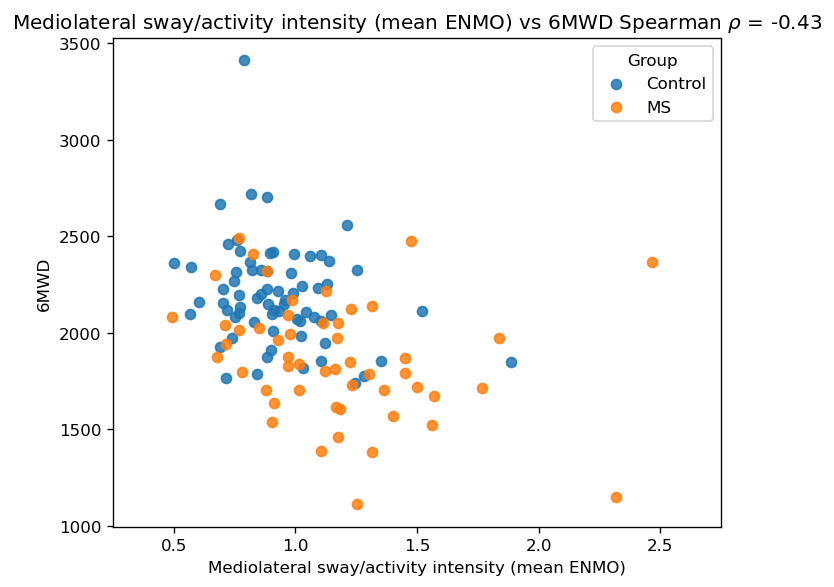

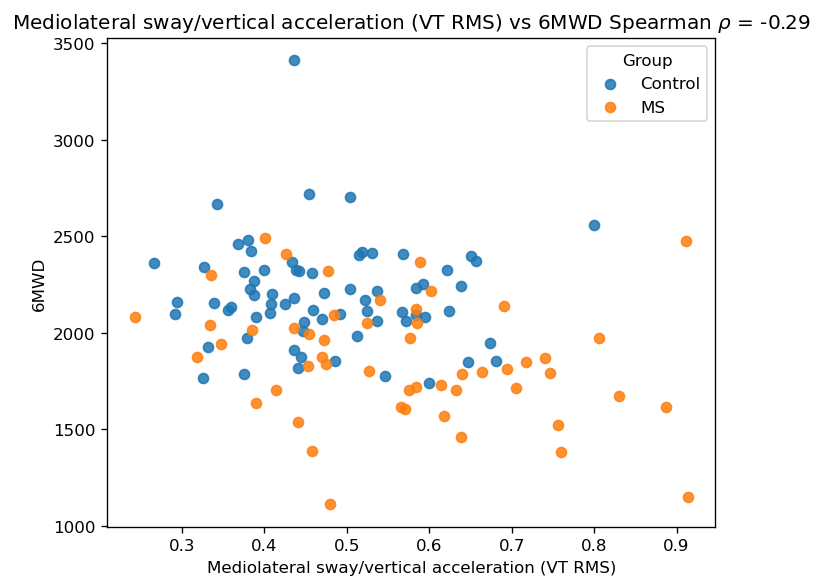

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

FEATURE_NAME_MAP = {
    "enmo_mean_g": "Mean ENMO (g, Euclidean Norm-1)",
    "cadence_hz": "Cadence (Hz, step frequency)",
    "jerk_mean_abs_gps": "Mean absolute jerk (g/s)",
    "ml_rms_g": "Mediolateral RMS acceleration (g)",
    "ml_spectral_entropy": "Mediolateral spectral entropy",
    "hr_ap": "Harmonic Ratio (AP)",
    "hr_vt": "Harmonic Ratio (VT)",
    "acf_step_regularity": "Step regularity (ACF at 1/cadence)",
    "cadence_slope_per_min": "Cadence slope per minute (Hz/min)",
    "step_time_cv_pct": "Step-time coefficient of variation (%)",
    "ml_over_enmo": "Mediolateral sway/activity intensity (mean ENMO)",
    "ml_over_vt": "Mediolateral sway/vertical acceleration (VT RMS)"
}

def _normalize_cohort(v):
    s = str(v).strip().lower()
    if s in {"c", "control", "0"}:
        return "Control"
    if s in {"m", "ms", "1"}:
        return "MS"
    return str(v)

def scatter_feature_vs_6mwd(df: pd.DataFrame, feature: str, group_col: str = "cohort"):
    d = df[[feature, "sixmwd", group_col]].copy()
    d["Group"] = d[group_col].map(_normalize_cohort)

    # Spearman r (overall only)
    res = spearmanr(d[feature].to_numpy(dtype=float),
                    d["sixmwd"].to_numpy(dtype=float),
                    nan_policy="omit")
    r_all = float(res.statistic)

    fig, ax = plt.subplots(figsize=(6, 5), dpi=120)

    # scatter points colored by group
    for g, gdf in d.groupby("Group"):
        ax.scatter(gdf[feature], gdf["sixmwd"], label=g, alpha=0.85)

    # overall best-fit (ordinary least squares) line
    x = d[feature].to_numpy(dtype=float)
    y = d["sixmwd"].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y)

    ax.set_xlabel(FEATURE_NAME_MAP.get(feature, feature))
    ax.set_ylabel("6MWD")
    ax.set_title(rf"{FEATURE_NAME_MAP.get(feature, feature)} vs 6MWD Spearman $\rho$ = {r_all:.2f}")
    ax.legend(title="Group")
    if feature == 'ml_over_enmo':
        ax.set_xlim([0.25, 2.75])
    # ax.grid(True, linestyle=":", linewidth=0.7)
    plt.tight_layout()
    return fig, r_all


# minimal fix: keep rows except those where cohort == 'M' and ml_over_enmo > 20
# feats_norm = feats_norm[~((feats_norm['cohort'] == 'M') & (feats_norm['ml_over_enmo'] > 20))]
print(feats_norm.shape)

# Draw both figures
_ = scatter_feature_vs_6mwd(feats_norm, "ml_over_enmo", group_col="cohort")
_ = scatter_feature_vs_6mwd(feats_norm, "ml_over_vt", group_col="cohort")
plt.show()

In [22]:
# Robust medians and distribution shapes for sway ratios by cohort
# Assumes `feats_norm` contains: 'cohort', 'ml_over_enmo', 'ml_over_vt'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- numeric summaries (per cohort) ---
metrics = ["ml_over_enmo", "ml_over_vt"]

def summarize_by_cohort(df: pd.DataFrame, col: str, n_boot: int = 10000) -> pd.DataFrame:
    def _one(s: pd.Series) -> pd.Series:
        s = s.dropna()
        n = len(s)
        mean = s.mean()
        std = s.std(ddof=1)
        median = s.median()
        q25 = s.quantile(0.25)
        q75 = s.quantile(0.75)
        iqr = q75 - q25
        mad = (s - median).abs().median()

        # 95% CI for mean
        if n >= 2 and np.isfinite(std):
            se = std / np.sqrt(n)
            try:
                from scipy.stats import t
                crit = t.ppf(0.975, df=n - 1)
            except Exception:
                crit = 1.96
            ci95_mean_lo = mean - crit * se
            ci95_mean_hi = mean + crit * se
        else:
            ci95_mean_lo = np.nan
            ci95_mean_hi = np.nan

        # 95% bootstrap CI for median
        if n >= 2:
            medians = np.array([
                np.median(np.random.choice(s, size=n, replace=True))
                for _ in range(n_boot)
            ])
            ci95_med_lo, ci95_med_hi = np.percentile(medians, [2.5, 97.5])
        else:
            ci95_med_lo, ci95_med_hi = np.nan, np.nan

        return pd.Series({
            "n": n,
            "mean": mean,
            "std": std,
            "median": median,
            "q25": q25,
            "q75": q75,
            "iqr": iqr,
            "mad": mad,
            # "ci95_mean_lo": ci95_mean_lo,
            # "ci95_mean_hi": ci95_mean_hi,
            "ci95_median_lo": ci95_med_lo,
            "ci95_median_hi": ci95_med_hi,
        })

    return df.groupby("cohort")[col].apply(_one).reset_index()



summary_tables = {col: summarize_by_cohort(feats_norm, col) for col in metrics}
for col, tbl in summary_tables.items():
    print(f"\n=== {col} ===")
    print(tbl)

# --- optional: mild winsorization to check outlier influence (2% tails within each cohort) ---
def winsorize_within_group(df: pd.DataFrame, group_col: str, col: str, p: float = 0.02) -> pd.Series:
    out = df[col].copy()
    for grp, idx in df.groupby(group_col).groups.items():
        s = df.loc[idx, col].dropna()
        if s.empty:
            continue
        lo, hi = s.quantile([p, 1 - p])
        out.loc[idx] = df.loc[idx, col].clip(lo, hi)
    return out

feats_w = feats_norm.copy()
for col in metrics:
    feats_w[col + "_w"] = winsorize_within_group(feats_norm, "cohort", col, p=0.02)

print("\n=== Winsorized medians (2% tails) ===")
print(
    feats_w.groupby("cohort")[[m + "_w" for m in metrics]]
           .median()
           .rename(columns={m + "_w": m + "_median_w" for m in metrics})
)

print(feats_norm.shape)

# --- boxplots (matplotlib, one figure per metric) ---
for col in metrics:
    plt.figure()

    # use hue=x to avoid palette warning, and suppress legend
    ax = sns.boxplot(
        data=feats_norm,
        x="cohort",
        y=col,
        hue="cohort",
        order=["C", "M"],
        palette=["#4C72B0", "#55A868"],
        showfliers=True,
        legend=False
    )

    # set proper tick labels safely
    ax.set_xticks(range(2))
    ax.set_xticklabels(["Control (C)", "MS (M)"])
    ax.set_xlabel("")
    ax.set_ylabel(FEATURE_NAME_MAP.get(col, col))

    if col == "ml_over_enmo":
        ax.set_ylim([0.25, 2.25])

    plt.title(f"{FEATURE_NAME_MAP.get(col, col)} by cohort (boxplot)")
    plt.tight_layout()
    plt.show()

# --- violin + box overlay (seaborn, if you prefer) ---
# import seaborn as sns
# for col in metrics:
#     plt.figure()
#     ax = sns.violinplot(data=feats_norm, x="cohort", y=col, inner=None, cut=0)
#     sns.boxplot(data=feats_norm, x="cohort", y=col, width=0.25,
#                 showcaps=True, boxprops={"facecolor": "none"},
#                 showfliers=True, whiskerprops={"linewidth": 1})
#     # Optional: jittered points to visualize outliers
#     # sns.stripplot(data=feats_norm, x="cohort", y=col, alpha=0.4, jitter=0.15, size=3)
#     ax.set_xlabel("cohort")
#     ax.set_ylabel(col)
#     ax.set_title(f"{col} by cohort (violin + box)")
#     plt.show()



=== ml_over_enmo ===
   cohort         level_1  ml_over_enmo
0       C               n     70.000000
1       C            mean      0.929061
2       C             std      0.225676
3       C          median      0.897570
4       C             q25      0.768843
5       C             q75      1.038638
6       C             iqr      0.269795
7       C             mad      0.131455
8       C  ci95_median_lo      0.849379
9       C  ci95_median_hi      0.953426
10      M               n     52.000000
11      M            mean      1.638609
12      M             std      3.467439
13      M          median      1.144781
14      M             q25      0.909102
15      M             q75      1.328327
16      M             iqr      0.419224
17      M             mad      0.226899
18      M  ci95_median_lo      0.982737
19      M  ci95_median_hi      1.225565

=== ml_over_vt ===
   cohort         level_1  ml_over_vt
0       C               n   70.000000
1       C            mean    0.474066
2   

NameError: name 'sns' is not defined

<Figure size 640x480 with 0 Axes>

In [32]:
# path to your folder
folder = Path("csv_preprocessed2")

# list all CSV files
files = list(folder.glob("*.csv"))

# count by prefix
n_control = sum(1 for f in files if f.name.startswith("C"))
n_ms = sum(1 for f in files if f.name.startswith("M"))

print(f"Total Control (C): {n_control}")
print(f"Total MS (M): {n_ms}")
print(f"Total files: {len(files)}")

Total Control (C): 70
Total MS (M): 52
Total files: 122


In [33]:
files

[PosixPath('csv_preprocessed2/C08_2016_1786.csv'),
 PosixPath('csv_preprocessed2/C23_2016_1947.csv'),
 PosixPath('csv_preprocessed2/C51_2017_2079.csv'),
 PosixPath('csv_preprocessed2/M57_2024_1520.csv'),
 PosixPath('csv_preprocessed2/M55_2024_1705.csv'),
 PosixPath('csv_preprocessed2/C30_2016_1853.csv'),
 PosixPath('csv_preprocessed2/M39_2020_1962.csv'),
 PosixPath('csv_preprocessed2/M48_2022_1840.csv'),
 PosixPath('csv_preprocessed2/C69_2017_2055.csv'),
 PosixPath('csv_preprocessed2/M14_2016_1868.csv'),
 PosixPath('csv_preprocessed2/M24_2018_2137.csv'),
 PosixPath('csv_preprocessed2/M02_2016_1941.csv'),
 PosixPath('csv_preprocessed2/M58_2024_1846.csv'),
 PosixPath('csv_preprocessed2/C66_2017_2095.csv'),
 PosixPath('csv_preprocessed2/C35_2016_2460.csv'),
 PosixPath('csv_preprocessed2/C02_2016_2216.csv'),
 PosixPath('csv_preprocessed2/C39_2016_2560.csv'),
 PosixPath('csv_preprocessed2/C41_2016_2251.csv'),
 PosixPath('csv_preprocessed2/C71_2017_2195.csv'),
 PosixPath('csv_preprocessed2/C

In [35]:
from pathlib import Path
import csv

# If you already have the list `files`, this will use it.
# Otherwise, uncomment to build from the directory:
# files = list(Path("csv_preprocessed2").glob("*.csv"))

# Extract prefixes like "C08", "M57", etc.
prefixes = [Path(p).name.split("_", 1)[0] for p in files]

# Sort with all "M*" first, then "C*", and alphabetically within each group
sorted_prefixes = sorted(prefixes, key=lambda s: (0 if s.startswith("M") else 1, s))

# Write to a CSV file readable by Excel
out_csv = Path("sub_ids.csv")
with out_csv.open("w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["prefix"])
    writer.writerows([[p] for p in sorted_prefixes])

print(f"Wrote {len(sorted_prefixes)} rows to {out_csv.resolve()}")

Wrote 122 rows to /mnt/sdb/arafat/6mw/sub_ids.csv
